In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE  #for class imbalance
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, recall_score
import pickle
import shap

data loading

In [2]:
df=pd.read_csv("C:\\Users\\vijet\\Downloads\\WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [3]:
df=df.drop("customerID",axis=1)
df_original = df.copy()

In [4]:
df.shape

(7043, 20)

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Total charges is showing up as obj, but it is float. Also customer is not required.

In [7]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [8]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
print(df["SeniorCitizen"].unique())

[0 1]


In [10]:
#checking unique values in each column
num_features= ["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
    if col not in num_features:
        print(col,df[col].unique())
        print("-"*50)


gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, 

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
#df["TotalCharges"] = df["TotalCharges"].astype(float)

In [13]:
df[df["TotalCharges"]==" "]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
len(df[df["TotalCharges"]==" "])

11

In [15]:
#this happened because of 11 rows having space instead of value in TotalCharges column. We can replace those space with string 0.0 and then convert the column to float type
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})

In [16]:
#convert the column to float type
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [18]:
#checking distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


*Insights*
- CustomerID column was removed because it was not required.
- No missing values in dataset other than
- Missing values in TotalCharges were replaced with 0
- Class imbalance identified in target column.

EDA

In [19]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [20]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


*numerical features analysis*

In [22]:
def plot_hist(df,col):
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    #calculate mean and median
    col_mean=df[col].mean()
    col_median=df[col].median()

    # add verticsl lines for mean and median
    plt.axvline(col_mean,color="red",linestyle="--",label="Mean")
    plt.axvline(col_median,color="green",linestyle="--",label="Median")
    plt.legend()
    plt.show()

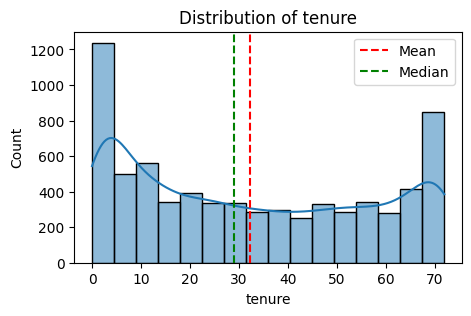

In [23]:
plot_hist(df,"tenure")

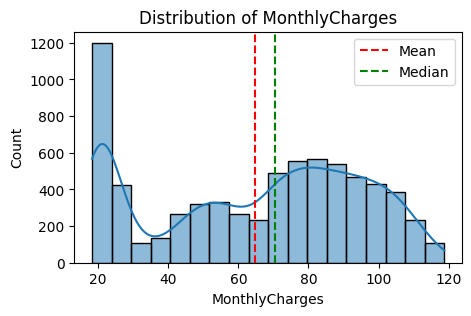

In [24]:
plot_hist(df,"MonthlyCharges")

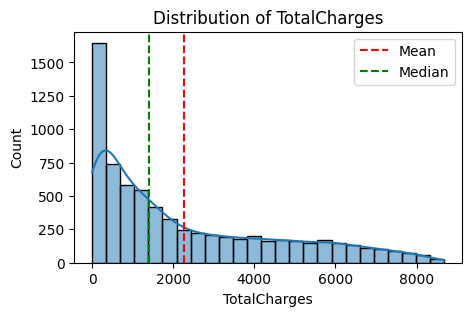

In [25]:
plot_hist(df,"TotalCharges")

Boxplot for numerical features.

In [26]:
def plot_boxplot(df,col):
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

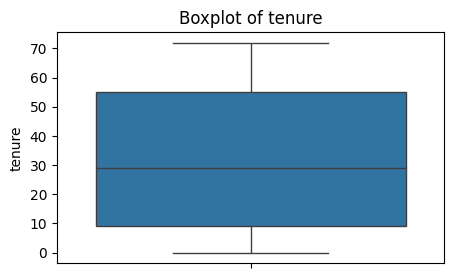

In [27]:
plot_boxplot(df,"tenure")

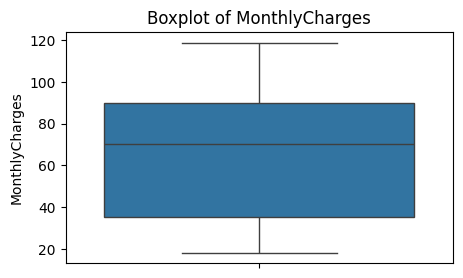

In [28]:
plot_boxplot(df,"MonthlyCharges")

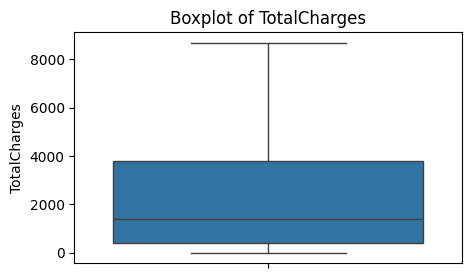

In [29]:
plot_boxplot(df,"TotalCharges")

Correlation heatmap for numerical heatmaps

<Axes: >

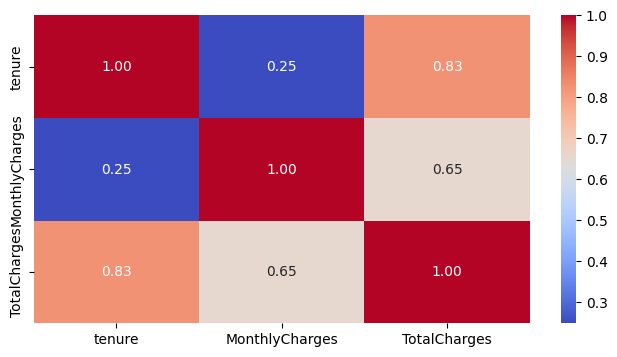

In [30]:
#colinearity check
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True, cmap="coolwarm", fmt=".2f")

Churn

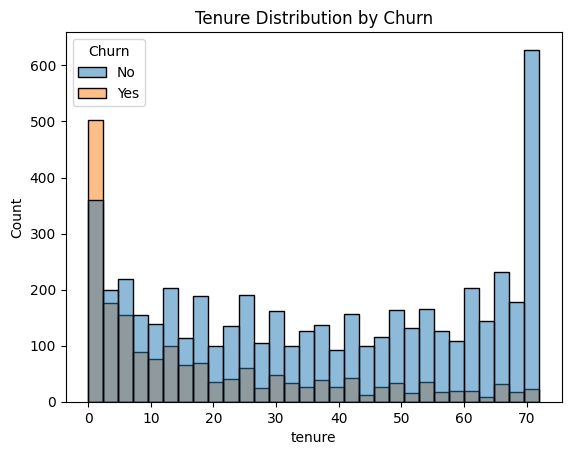

In [31]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

INSIGHT:
Customers with a lower tenure show a higher churn rate.
This suggests that new customers are more likely to leave early,
indicating need for better onboarding or early engagement strategies.
Long-term customers show higher retention, indicating loyalty increases over time.

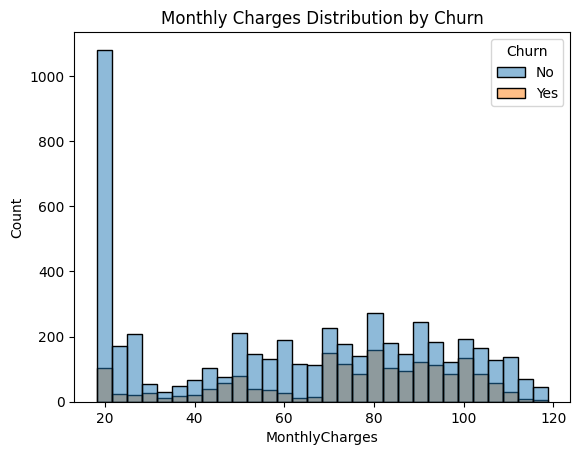

In [32]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

INSIGHTS:
Customers with higher monthly charges tend to churn more

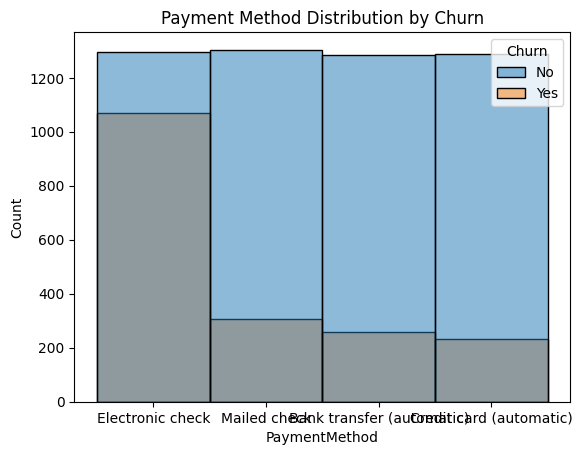

In [33]:
sns.histplot(data=df, x="PaymentMethod", hue="Churn", bins=30)
plt.title("Payment Method Distribution by Churn")
plt.show()

INSIGHTS:
Customers using electronic check show higher churn rates,
possibly indicating a less stable customer segment.

Categorical features analysis

In [34]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [36]:
obj_cols=df.select_dtypes(include="object").columns.to_list()
obj_cols = ["SeniorCitizen"] + obj_cols
obj_cols

C:\Users\vijet\AppData\Local\Temp\ipykernel_10044\1600594505.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols=df.select_dtypes(include="object").columns.to_list()


['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

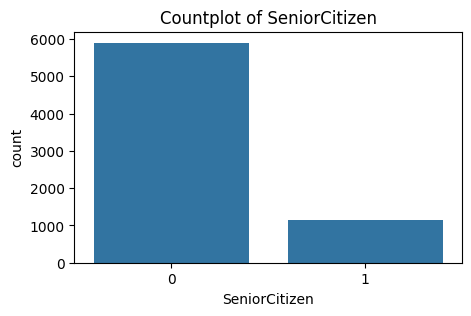

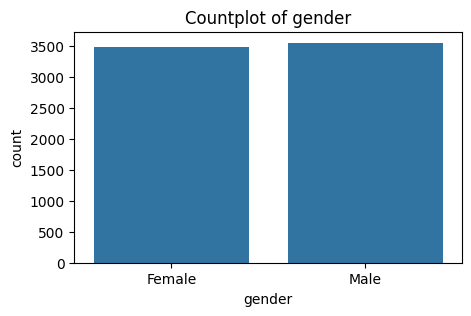

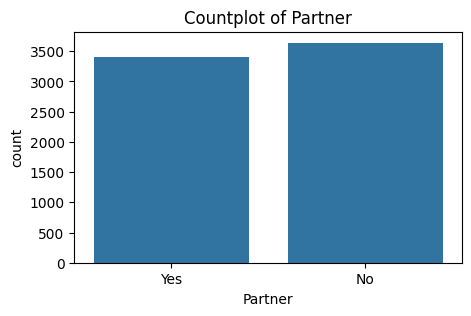

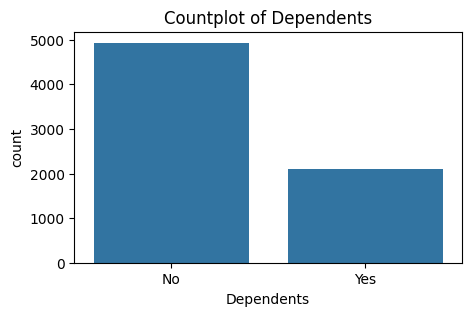

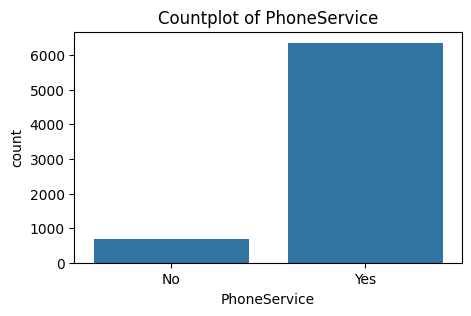

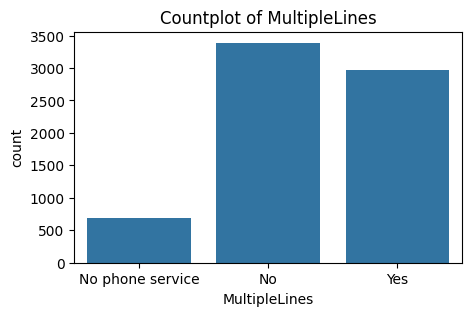

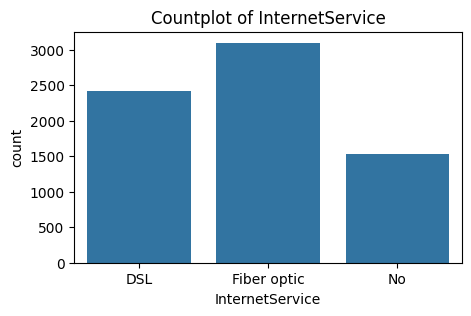

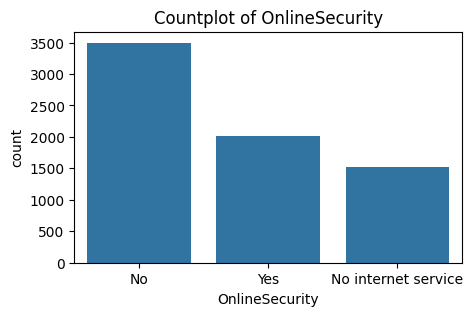

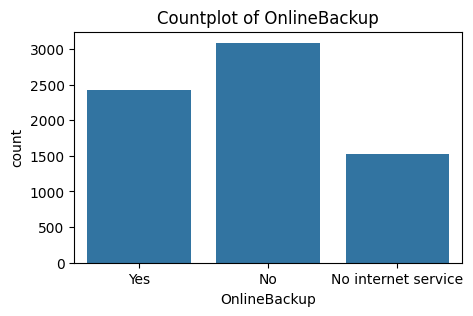

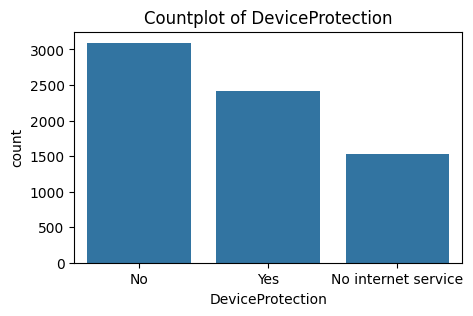

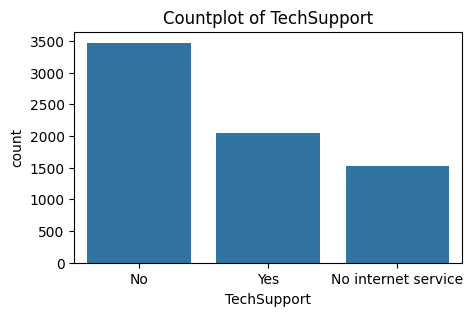

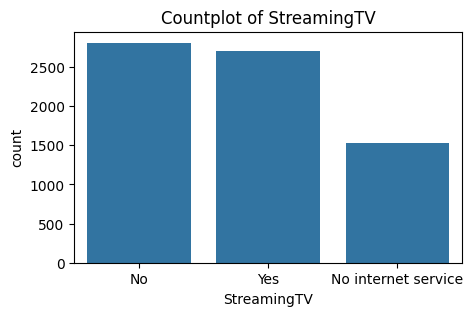

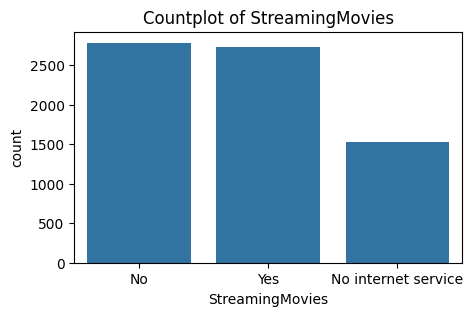

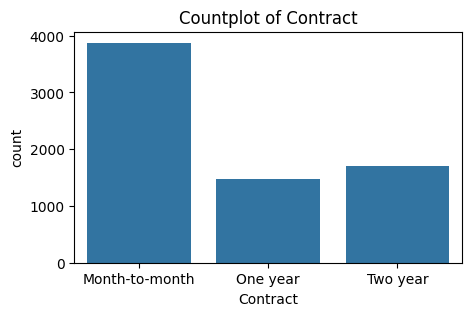

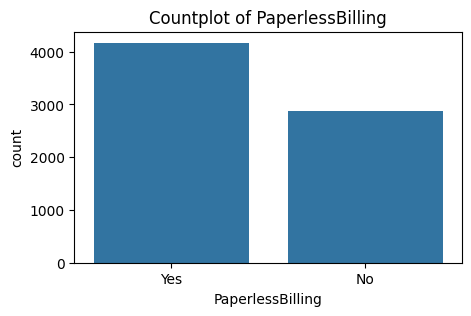

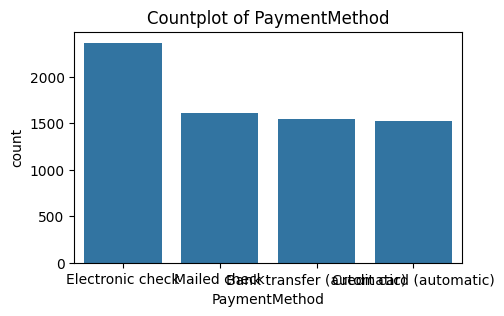

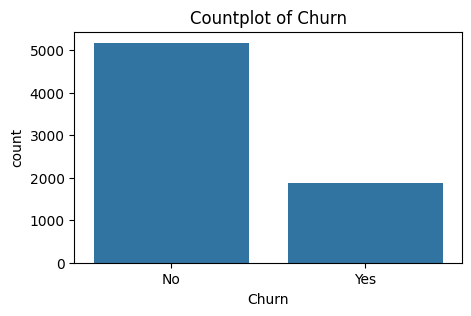

In [37]:
#countplot for categorical columns
for col in obj_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()

Data Preprocessing

KEY INSIGHTS:

1. New customers are at the highest risk of churn
2. High monthly charges increase churn probability
3. Long-term contracts significantly reduce churn
4. Certain payment methods are associated with higher churn

In [38]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Label Encoding of target

In [39]:
df["Churn"] = df["Churn"].replace({"Yes":1,"No":0})

In [40]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [41]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label encoding for categorical feartures

In [42]:
# reset to original data to avoid double-encoding when rerunning cells
df = df_original.copy()

# ensure numeric columns are truly numeric before categorical encoding
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# identify categorical columns only (exclude known numeric features)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
obj_cols = [col for col in df.columns if col not in numeric_cols]

In [43]:
print(obj_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [44]:
# initialize a dictionary to store label encoders for each column
encoders = {}

# apply label encoding only to categorical columns
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

if "Churn" in encoders:
    y_encoder = encoders.pop("Churn")

# save feature encoders using pickle
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


In [45]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [46]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [47]:
# separate features and target
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [48]:
#Train test data 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


Apply SMOTE (synthetic minority oversampling technique)

In [50]:
smote = SMOTE(random_state=42)

In [51]:
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [52]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


Model Training

In [53]:
#training with default hyper parameters
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [54]:
#dictionary to store cross validation scores
cv_scores = {}

#perform 5 fold cross validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring="recall")
    cv_scores[model_name] = scores
    print(f"{model_name} Cross Validation Recall: {np.mean(scores):.2f}")
    print("-"*50)

for model_name, scores in cv_scores.items():
    print(f"{model_name} Mean Recall: {np.mean(scores):.3f}")

Training Decision Tree with default parameters
Decision Tree Cross Validation Recall: 0.78
--------------------------------------------------
Training Random Forest with default parameters
Random Forest Cross Validation Recall: 0.84
--------------------------------------------------
Training XGBoost with default parameters
XGBoost Cross Validation Recall: 0.82
--------------------------------------------------
Decision Tree Mean Recall: 0.778
Random Forest Mean Recall: 0.836
XGBoost Mean Recall: 0.825


In [55]:
cv_scores

{'Decision Tree': array([0.58454106, 0.59975816, 0.88029021, 0.90821256, 0.91908213]),
 'Random Forest': array([0.59903382, 0.66989117, 0.96977025, 0.97222222, 0.9673913 ]),
 'XGBoost': array([0.54951691, 0.64933495, 0.96977025, 0.98067633, 0.97463768])}

In [56]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train_smote, y_train_smote)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [57]:
print(y_test.value_counts())
y_prob = best_model.predict_proba(x_test)[:, 1]

Churn
0    1036
1     373
Name: count, dtype: int64


Model Evaluation:

In [76]:
# evaluate on test data
y_test_pred = best_model.predict(x_test)
print("Accuracy score:\n",accuracy_score(y_test, y_test_pred))
print("Classification Report:\n",classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_test_pred))
print("Recall Score:\n",recall_score(y_test, y_test_pred))

Accuracy score:
 0.7665010645848119
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.79      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

Confusion Matrix:
 [[786 250]
 [ 79 294]]
Recall Score:
 0.7882037533512064


ROC AUC Score: 0.849


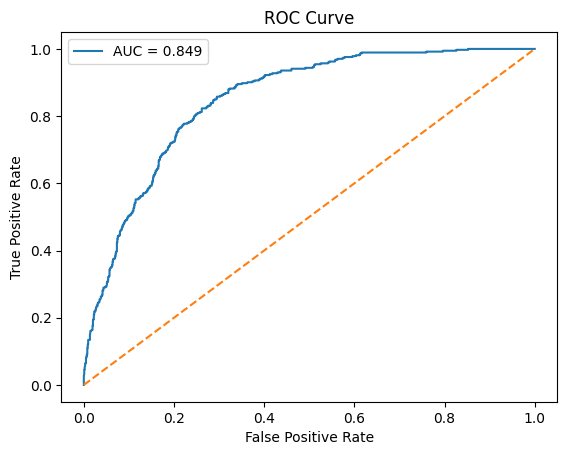

In [73]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.3f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [60]:
#save the trained model using pickle
model_data={"model": best_model, "feature_names": x_train_smote.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

Load the saved model and build a predicton system

In [61]:
#load the model and encoders to make predictions on new data
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)
    
loaded_model = model_data["model"]
feature_names = model_data["feature_names"]

In [62]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [63]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}
input_df = pd.DataFrame([input_data])

# keep numeric columns numeric before encoding
input_df["TotalCharges"] = pd.to_numeric(input_df["TotalCharges"], errors="coerce").fillna(0.0)

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

numeric_cols = {"tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"}

# encode categorical features using same label encoders used during training
for col, encoder in encoders.items():
    if col in input_df.columns and col not in numeric_cols:
        input_df[col] = encoder.transform(input_df[col].astype(str))

pred = loaded_model.predict(input_df)
pred_prob = loaded_model.predict_proba(input_df)
print(pred)

print(f"Prediction: {'Churn' if pred[0]==1 else 'No Churn'}")
print(f"Prediction Probability: {pred_prob}")

[1]
Prediction: Churn
Prediction Probability: [[0.3526906 0.6473094]]


In [ ]:
# SHAP setup 
explainer = shap.TreeExplainer(best_model)

# plots 
shap_sample = x_test.sample(n=min(200, len(x_test)), random_state=42)

# For binary classification, use SHAP values for the churn class (class 1)
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif getattr(shap_values, "ndim", 0) == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP ready. Sample size:", len(shap_sample))

SHAP ready. Sample size: 200


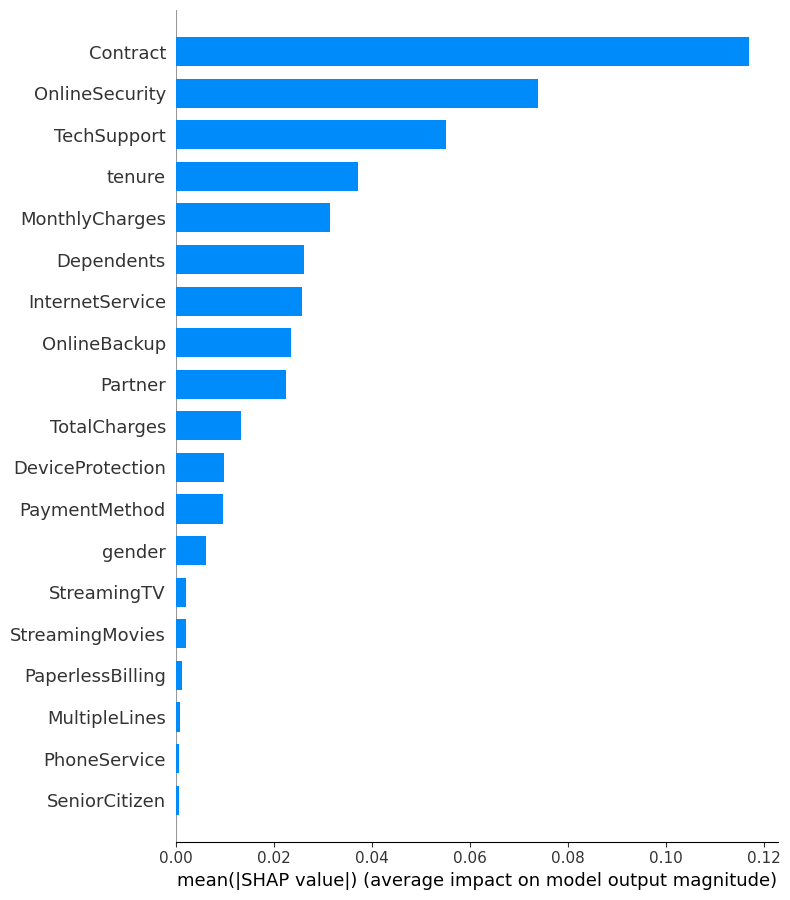

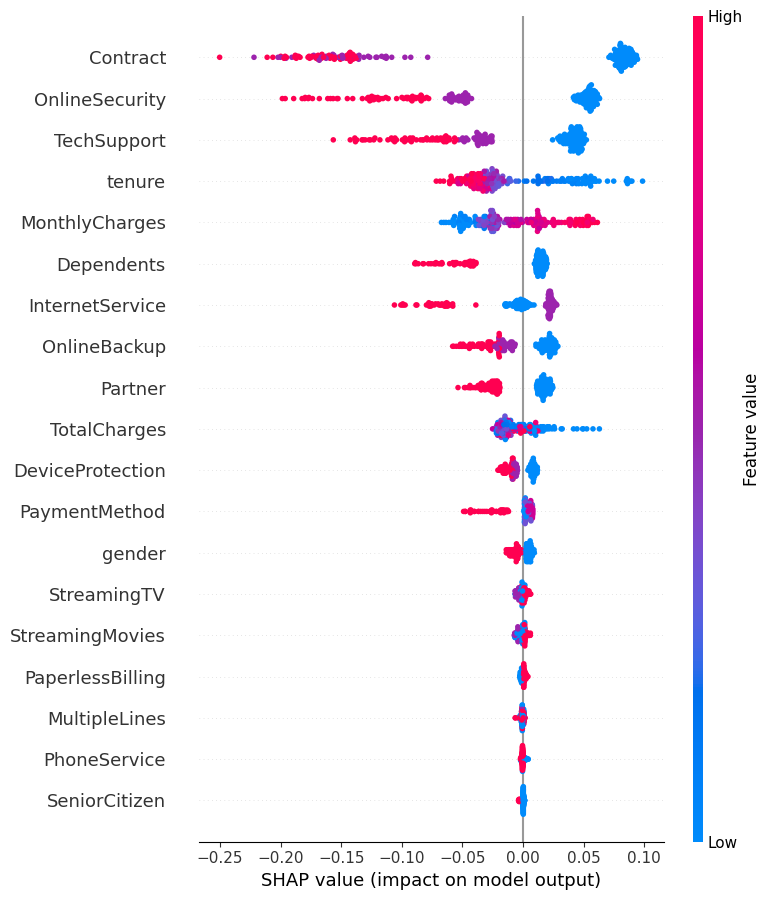

In [72]:
# Plot 1: overall feature importance
shap.summary_plot(shap_values, shap_sample, plot_type="bar")

# Plot 2: how each feature pushes churn probability up or down
shap.summary_plot(shap_values, shap_sample)